In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
#Load the data
df=pd.read_csv('/content/esports_gaming_biometrics_250k.csv')

In [3]:
#first 5 rows of the data
df.head()

,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss


In [4]:
#Summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Player_ID          250000 non-null  object 
 1   Age                250000 non-null  int64  
 2   Game_Genre         250000 non-null  object 
 3   PlayTime_Hours     250000 non-null  float64
 4   Sleep_Hours        250000 non-null  float64
 5   Energy_Drinks      250000 non-null  int64  
 6   Screen_Brightness  237452 non-null  float64
 7   Blue_Light_Filter  250000 non-null  object 
 8   APM                250000 non-null  int64  
 9   Heart_Rate_BPM     250000 non-null  int64  
 10  HRV_Score          245066 non-null  float64
 11  Reaction_Time_ms   250000 non-null  float64
 12  Match_Outcome      250000 non-null  object 
dtypes: float64(5), int64(4), object(4)
memory usage: 24.8+ MB


In [5]:
# check the missing values
df.isnull().sum()

,0
Player_ID,0
Age,0
Game_Genre,0
PlayTime_Hours,0
Sleep_Hours,0
Energy_Drinks,0
Screen_Brightness,12548
Blue_Light_Filter,0
APM,0
Heart_Rate_BPM,0


In [6]:
#Handle the missing values
df['Screen_Brightness'] = df['Screen_Brightness'].fillna(df['Screen_Brightness'].median())
df['HRV_Score'] = df['HRV_Score'].fillna(df['HRV_Score'].median())

In [7]:
# check the missing values after handling
df.isnull().sum()

,0
Player_ID,0
Age,0
Game_Genre,0
PlayTime_Hours,0
Sleep_Hours,0
Energy_Drinks,0
Screen_Brightness,0
Blue_Light_Filter,0
APM,0
Heart_Rate_BPM,0


In [8]:
# Check for Inconsistent Labels in Categorical Columns
print('Unique values for Game_Genre:', df['Game_Genre'].unique())
print('Unique values for Blue_Light_Filter:', df['Blue_Light_Filter'].unique())
print('Unique values for Match_Outcome:', df['Match_Outcome'].unique())

Unique values for Game_Genre: ['FPS' 'Battle Royale' 'MOBA' 'Fighting']
Unique values for Blue_Light_Filter: ['Yes' 'No']
Unique values for Match_Outcome: ['Loss' 'Win']


In [9]:
#Business Rule Validation
invalid_playtime = df[df['PlayTime_Hours'] < 0]
if not invalid_playtime.empty:
    print(f"Found {len(invalid_playtime)} rows with negative PlayTime_Hours. Displaying first 5:\n{invalid_playtime.head()}")
else:
    print("All PlayTime_Hours are non-negative.")

# Example physiological ranges for Heart_Rate_BPM and HRV_Score
# (These are general and might need domain-specific refinement)
min_heart_rate = 30 # very low for athletes
max_heart_rate = 220 # max for young adults during intense exercise

min_hrv_score = 10 # very low for unhealthy individuals
max_hrv_score = 200 # very high for very healthy individuals

invalid_heart_rate = df[(df['Heart_Rate_BPM'] < min_heart_rate) | (df['Heart_Rate_BPM'] > max_heart_rate)]
invalid_hrv_score = df[(df['HRV_Score'] < min_hrv_score) | (df['HRV_Score'] > max_hrv_score)]

if not invalid_heart_rate.empty:
    print(f"\nFound {len(invalid_heart_rate)} rows with Heart_Rate_BPM outside of [{min_heart_rate}-{max_heart_rate}]. Displaying first 5:\n{invalid_heart_rate.head()}")
else:
    print(f"\nAll Heart_Rate_BPM values are within [{min_heart_rate}-{max_heart_rate}].")

if not invalid_hrv_score.empty:
    print(f"\nFound {len(invalid_hrv_score)} rows with HRV_Score outside of [{min_hrv_score}-{max_hrv_score}]. Displaying first 5:\n{invalid_hrv_score.head()}")
else:
    print(f"\nAll HRV_Score values are within [{min_hrv_score}-{max_hrv_score}].")

All PlayTime_Hours are non-negative.

All Heart_Rate_BPM values are within [30-220].

All HRV_Score values are within [10-200].


In [10]:
#Outlier Detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

numerical_cols_for_outliers = ['Age', 'PlayTime_Hours', 'APM', 'Heart_Rate_BPM', 'HRV_Score', 'Reaction_Time_ms']

print("\n--- Outlier Detection Results (IQR Method) ---")
for col in numerical_cols_for_outliers:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    if not outliers.empty:
        print(f"\nColumn: {col}")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Lower Bound: {lb:.2f}, Upper Bound: {ub:.2f}")
        print(f"  Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")
        # Optionally display first 5 outliers
        # print(f"  First 5 outliers:\n{outliers[[col]].head()}")
    else:
        print(f"\nNo outliers detected for column: {col}")


--- Outlier Detection Results (IQR Method) ---

Column: Age
  Number of outliers: 1527
  Lower Bound: 12.50, Upper Bound: 32.50
  Percentage of outliers: 0.61%

Column: PlayTime_Hours
  Number of outliers: 12054
  Lower Bound: -3.41, Upper Bound: 7.60
  Percentage of outliers: 4.82%

Column: APM
  Number of outliers: 221
  Lower Bound: -37.00, Upper Bound: 443.00
  Percentage of outliers: 0.09%

Column: Heart_Rate_BPM
  Number of outliers: 1412
  Lower Bound: 57.50, Upper Bound: 109.50
  Percentage of outliers: 0.56%

Column: HRV_Score
  Number of outliers: 2742
  Lower Bound: 56.42, Upper Bound: 121.46
  Percentage of outliers: 1.10%

Column: Reaction_Time_ms
  Number of outliers: 1927
  Lower Bound: 211.42, Upper Bound: 314.11
  Percentage of outliers: 0.77%


# visualizations by matplotlib


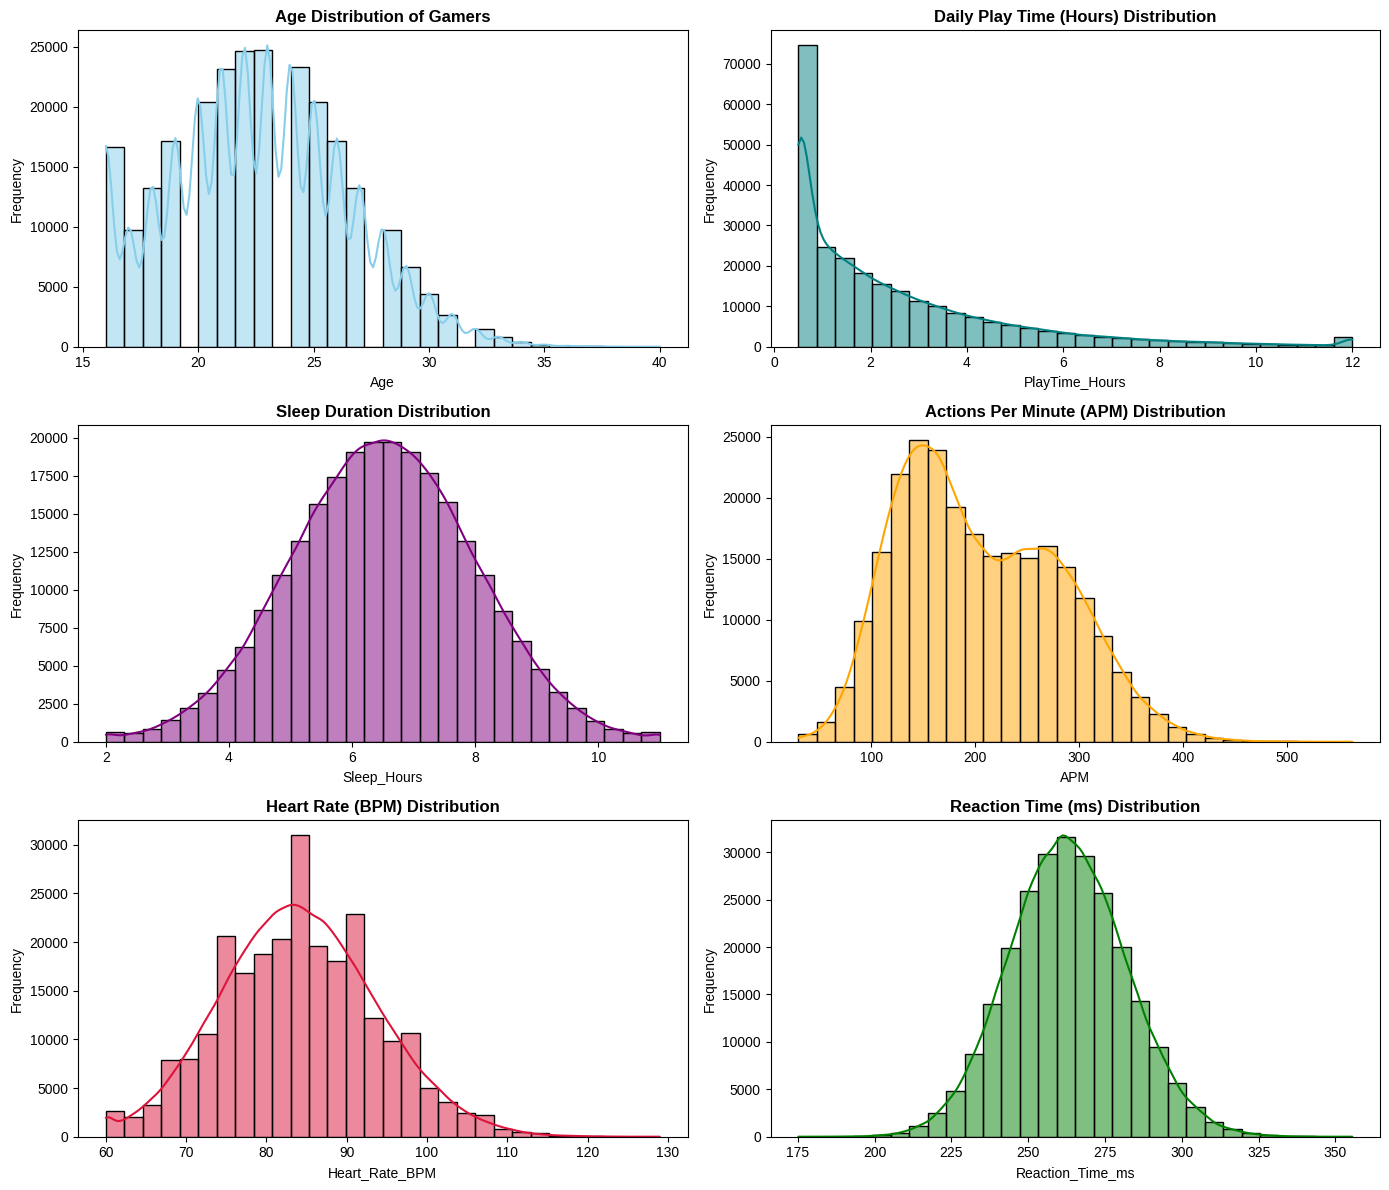


DESCRIPTION & INTERPRETATION:
1. Age Histogram: Shows the demographic age spread of players to verify skewness.
2. PlayTime_Hours Histogram: Visualizes gameplay intensity per day.
3. Sleep_Hours Histogram: Captures resting habits across the cohort.
4. APM Histogram: Measures mechanical speed and distribution of actions per minute.
5. Heart_Rate_BPM Histogram: Highlights cardiovascular strain during gaming sessions.
6. Reaction_Time_ms Histogram: Shows distribution of reflexes in milliseconds.



In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plt.style.use('seaborn-v0_8-whitegrid')

metrics = [
    ('Age', 'Skyblue', 'Age Distribution of Gamers'),
    ('PlayTime_Hours', 'Teal', 'Daily Play Time (Hours) Distribution'),
    ('Sleep_Hours', 'Purple', 'Sleep Duration Distribution'),
    ('APM', 'Orange', 'Actions Per Minute (APM) Distribution'),
    ('Heart_Rate_BPM', 'Crimson', 'Heart Rate (BPM) Distribution'),
    ('Reaction_Time_ms', 'Green', 'Reaction Time (ms) Distribution')
]

for ax, (col, color, title) in zip(axes.flatten(), metrics):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print('''
DESCRIPTION & INTERPRETATION:
1. Age Histogram: Shows the demographic age spread of players to verify skewness.
2. PlayTime_Hours Histogram: Visualizes gameplay intensity per day.
3. Sleep_Hours Histogram: Captures resting habits across the cohort.
4. APM Histogram: Measures mechanical speed and distribution of actions per minute.
5. Heart_Rate_BPM Histogram: Highlights cardiovascular strain during gaming sessions.
6. Reaction_Time_ms Histogram: Shows distribution of reflexes in milliseconds.
''')

# **Visualizations by seaborn**

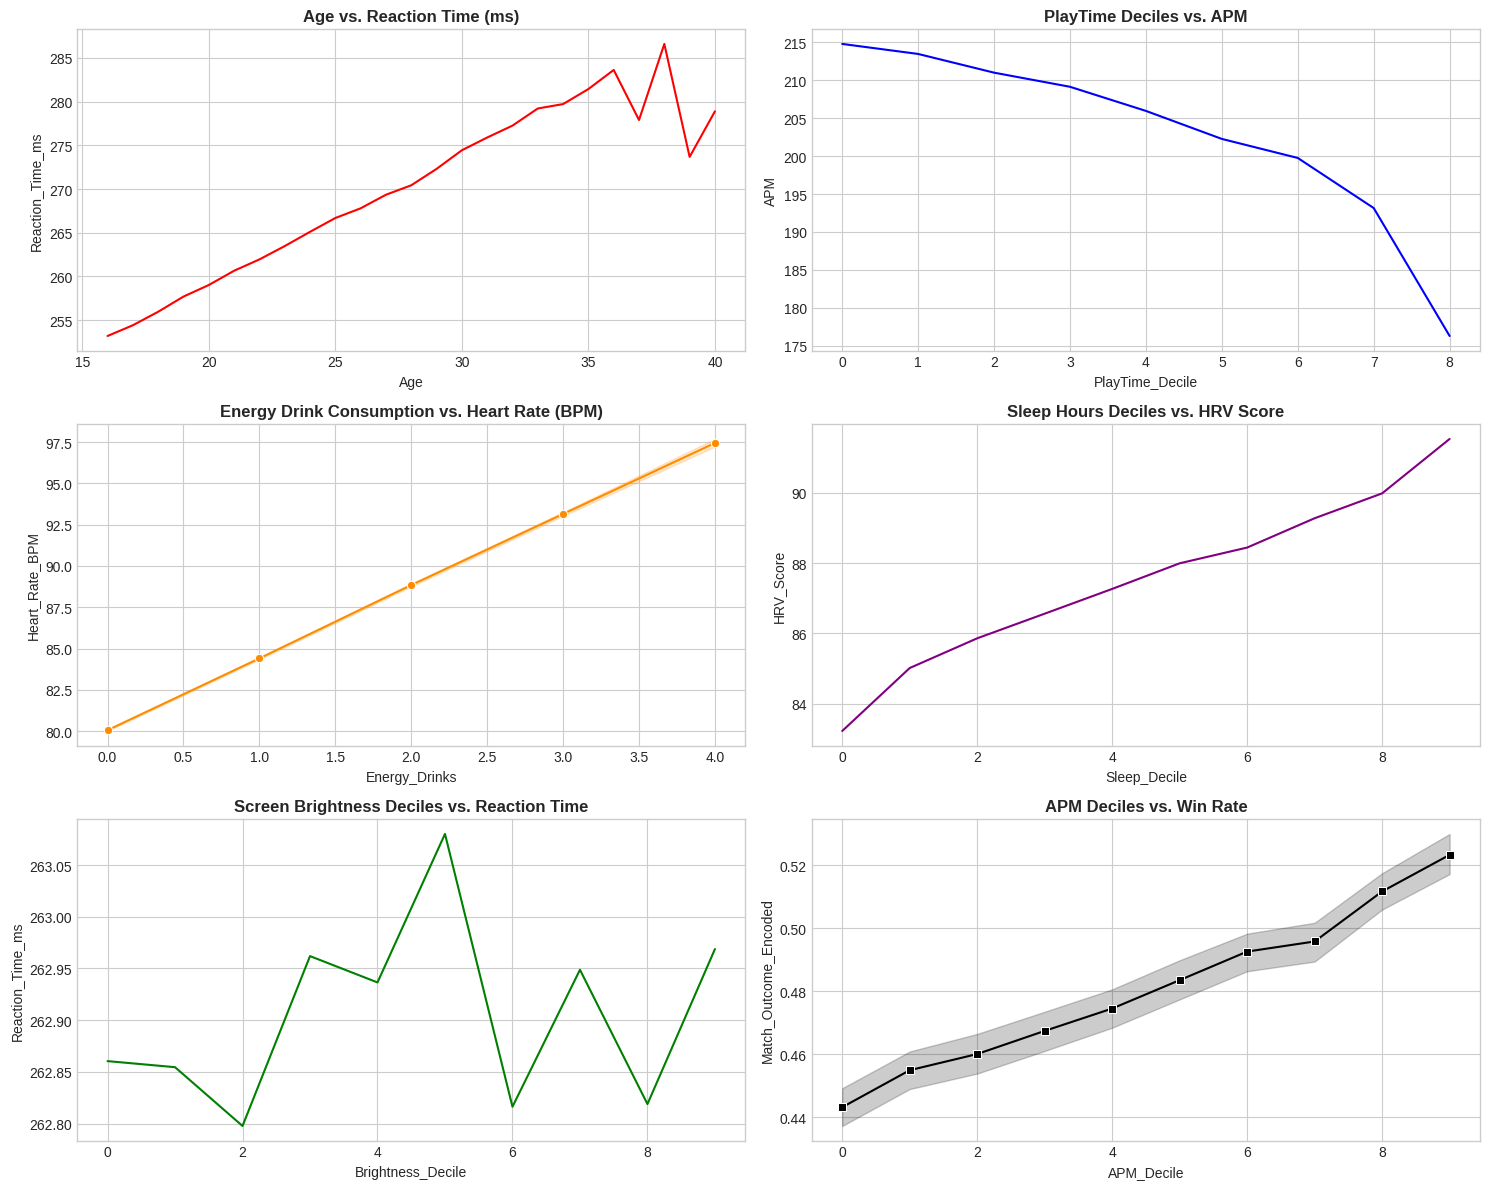


DESCRIPTION & INTERPRETATION:
1. Age vs Reaction Time: Tracks average reflex latency progression across age brackets.
2. PlayTime Deciles vs APM: Evaluates mechanical output changes over relative playtime quantiles.
3. Energy Drinks vs Heart Rate: Measures cardiovascular response to varying energy drink intakes.
4. Sleep Deciles vs HRV: Observes heart rate variability recovery across sleep duration deciles.
5. Brightness Deciles vs Reaction Time: Evaluates fatigue and latency impacts across screen brightness levels.
6. APM Deciles vs Win Rate: Tracks the correlation between mechanical speed quantiles and win probabilities.



In [12]:
df['Match_Outcome_Encoded'] = df['Match_Outcome'].map({'Loss': 0, 'Win': 1})

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Plot 1: Reaction Time vs Age
sns.lineplot(data=df, x='Age', y='Reaction_Time_ms', ax=axes[0, 0], color='red', errorbar=None)
axes[0, 0].set_title('Age vs. Reaction Time (ms)', fontweight='bold')

# Plot 2: APM vs PlayTime Hours Deciles
playtime_bins = pd.qcut(df['PlayTime_Hours'], q=10, duplicates='drop')
df['PlayTime_Decile'] = playtime_bins.cat.codes
sns.lineplot(data=df, x='PlayTime_Decile', y='APM', ax=axes[0, 1], color='blue', errorbar=None)
axes[0, 1].set_title('PlayTime Deciles vs. APM', fontweight='bold')

# Plot 3: Heart Rate vs Energy Drinks
sns.lineplot(data=df, x='Energy_Drinks', y='Heart_Rate_BPM', ax=axes[1, 0], color='darkorange', marker='o')
axes[1, 0].set_title('Energy Drink Consumption vs. Heart Rate (BPM)', fontweight='bold')

# Plot 4: HRV Score vs Sleep Hours Deciles
sleep_bins = pd.qcut(df['Sleep_Hours'], q=10, duplicates='drop')
df['Sleep_Decile'] = sleep_bins.cat.codes
sns.lineplot(data=df, x='Sleep_Decile', y='HRV_Score', ax=axes[1, 1], color='purple', errorbar=None)
axes[1, 1].set_title('Sleep Hours Deciles vs. HRV Score', fontweight='bold')

# Plot 5: Reaction Time vs Screen Brightness Deciles
bright_bins = pd.qcut(df['Screen_Brightness'], q=10, duplicates='drop')
df['Brightness_Decile'] = bright_bins.cat.codes
sns.lineplot(data=df, x='Brightness_Decile', y='Reaction_Time_ms', ax=axes[2, 0], color='green', errorbar=None)
axes[2, 0].set_title('Screen Brightness Deciles vs. Reaction Time', fontweight='bold')

# Plot 6: Win Rate vs APM Deciles
apm_bins = pd.qcut(df['APM'], q=10, duplicates='drop')
df['APM_Decile'] = apm_bins.cat.codes
sns.lineplot(data=df, x='APM_Decile', y='Match_Outcome_Encoded', ax=axes[2, 1], color='black', marker='s')
axes[2, 1].set_title('APM Deciles vs. Win Rate', fontweight='bold')

plt.tight_layout()
plt.show()

print('''
DESCRIPTION & INTERPRETATION:
1. Age vs Reaction Time: Tracks average reflex latency progression across age brackets.
2. PlayTime Deciles vs APM: Evaluates mechanical output changes over relative playtime quantiles.
3. Energy Drinks vs Heart Rate: Measures cardiovascular response to varying energy drink intakes.
4. Sleep Deciles vs HRV: Observes heart rate variability recovery across sleep duration deciles.
5. Brightness Deciles vs Reaction Time: Evaluates fatigue and latency impacts across screen brightness levels.
6. APM Deciles vs Win Rate: Tracks the correlation between mechanical speed quantiles and win probabilities.
''')

# **Visualizations by Plotly**

In [13]:
fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
        [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]
    ],
    subplot_titles=[
        'Game Genre Share',
        'Match Outcome Breakdown',
        'Blue Light Filter Usage',
        'Energy Drink Intake Units',
        'Age Group Proportions',
        'Sleep Duration Tier Breakdown'])

# Define custom color palettes for each chart
genre_colors = ['#FF6347', '#4682B4', '#3CB371', '#FFD700'] # Tomato, SteelBlue, MediumSeaGreen, Gold
outcome_colors = ['#FF4500', '#32CD32'] # OrangeRed, LimeGreen
blue_light_colors = ['#6A5ACD', '#87CEEB'] # SlateBlue, SkyBlue
energy_drink_colors = ['#ADD8E6', '#87CEFA', '#6495ED', '#4169E1', '#1E90FF'] # LightBlue, LightSkyBlue, CornflowerBlue, RoyalBlue, DodgerBlue
age_group_colors = ['#DA70D6', '#BA55D3', '#9370DB', '#8A2BE2'] # Orchid, MediumOrchid, MediumPurple, BlueViolet
sleep_colors = ['#FFB6C1', '#FF69B4', '#C71585', '#800080'] # LightPink, DeepPink, MediumVioletRed, Purple

# 1. Game Genre Share
genre_counts = df['Game_Genre'].value_counts()

fig.add_trace(
    go.Pie(
        labels=genre_counts.index,
        values=genre_counts.values,
        textinfo='percent',
        hovertemplate='%{label}: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=genre_colors),
    row=1, col=1)

# 2. Match Outcome Share
outcome_counts = df['Match_Outcome'].value_counts()

fig.add_trace(
    go.Pie(
        labels=outcome_counts.index,
        values=outcome_counts.values,
        textinfo='percent',
        hovertemplate='%{label}: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=outcome_colors),
    row=1, col=2)

# 3. Blue Light Filter Usage Share
blue_light_counts = df['Blue_Light_Filter'].value_counts()

fig.add_trace(
    go.Pie(
        labels=blue_light_counts.index,
        values=blue_light_counts.values,
        textinfo='percent',
        hovertemplate='%{label}: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=blue_light_colors),
    row=1, col=3)

# 4. Energy Drink Segments
energy_counts = df['Energy_Drinks'].value_counts().sort_index()

fig.add_trace(
    go.Pie(
        labels=energy_counts.index.astype(str),
        values=energy_counts.values,
        textinfo='percent',
        hovertemplate='%{label} drinks: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=energy_drink_colors),
    row=2, col=1)

# 5. Age Bracket Proportions
age_groups = pd.cut(
    df['Age'],
    bins=[15, 20, 25, 30, 40])

age_counts = age_groups.value_counts().sort_index()

fig.add_trace(
    go.Pie(
        labels=age_counts.index.astype(str),
        values=age_counts.values,
        textinfo='percent',
        hovertemplate='%{label}: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=age_group_colors
    ),
    row=2, col=2)

# 6. Sleep Duration Categories
sleep_groups = pd.cut(
    df['Sleep_Hours'],
    bins=[0, 5, 7, 9, 12])

sleep_counts = sleep_groups.value_counts().sort_index()
fig.add_trace(
    go.Pie(
        labels=sleep_counts.index.astype(str),
        values=sleep_counts.values,
        textinfo='percent',
        hovertemplate='%{label}: %{value} players<br>%{percent}<extra></extra>',
        marker_colors=sleep_colors),
    row=2, col=3)

# Layout
fig.update_layout(
    title='Esports Player Profile Breakdown',
    height=800,
    width=1200,
    showlegend=True)
fig.show()

print('''
DESCRIPTION & INTERPRETATION:
1. Game Genre Share: Highlights global genre composition.
2. Outcome Breakdown: Demonstrates binary output class ratio.
3. Blue Light Filter Share: Quantifies display filter adoption.
4. Energy Drink Segments: Illustrates portion distribution of caffeinated intake.
5. Age Group Proportions: Categorizes demographics into defined brackets.
6. Sleep Tier Breakdown: Evaluates percentage of sleep-deprived vs well-rested players.
''')


DESCRIPTION & INTERPRETATION:
1. Game Genre Share: Highlights global genre composition.
2. Outcome Breakdown: Demonstrates binary output class ratio.
3. Blue Light Filter Share: Quantifies display filter adoption.
4. Energy Drink Segments: Illustrates portion distribution of caffeinated intake.
5. Age Group Proportions: Categorizes demographics into defined brackets.
6. Sleep Tier Breakdown: Evaluates percentage of sleep-deprived vs well-rested players.



# **Encoding and Normalizing**


In [14]:
# Make a copy
df_encoded = df.copy()

# Drop Player ID
df_encoded = df_encoded.drop('Player_ID', axis=1)

# Separate Target
y = df_encoded['Match_Outcome']
X = df_encoded.drop('Match_Outcome', axis=1)

# Categorical columns
categorical_cols = [
    'Game_Genre',
    'Blue_Light_Filter'
]

# Numerical columns
numerical_cols = [
    'Age',
    'PlayTime_Hours',
    'Sleep_Hours',
    'Energy_Drinks',
    'Screen_Brightness',
    'APM',
    'Heart_Rate_BPM',
    'HRV_Score',
    'Reaction_Time_ms'
]

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Encode Target
y = y.map({
    'Loss': 0,
    'Win': 1
})

# Normalize Numerical Features
scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(
    X[numerical_cols]
)

X.head()
y.head()

,Match_Outcome
0,0
1,1
2,1
3,1
4,0
